In [ ]:
# 1. Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = '/content/drive/MyDrive/FYP_Project/Universal_Dataset.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    print("📂 Unzipping dataset... (This takes 10-20 seconds)")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Unzipped successfully!")
else:
    print("✅ Dataset already exists. Skipping unzip.")

train_dir = os.path.join(extract_path, '04_Universal_Dataset', 'Train')
val_dir = os.path.join(extract_path, '04_Universal_Dataset', 'Val')

print(f"Train Path: {train_dir}")
print(f"Images in Real Train: {len(os.listdir(os.path.join(train_dir, 'Real')))}")

Mounted at /content/drive
📂 Unzipping dataset... (This takes 10-20 seconds)
✅ Unzipped successfully!
Train Path: /content/dataset/04_Universal_Dataset/Train
Images in Real Train: 10149


📂 Saving results to: /content/drive/MyDrive/FYP_Project/Models/EfficientNetV2_S/Final_Prototype_Universal_EfficientNet_ConfigD
🚀 Starting EfficientNetV2_S - Final_Prototype_Universal_EfficientNet_ConfigD on cuda...
📊 Dataset Stats: Train=20598, Val=3998
['Fake', 'Real']
⏳ Loading EfficientNetV2_S weights...
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 215MB/s]


⚙️ Using Adam (LR=1e-05)

Epoch 1/50
----------
Train Loss: 0.4153 Acc: 0.8001
Val Loss: 0.0632 Acc: 0.9880
   📊 Precision: 0.9822 | Recall: 0.9940 | Spec: 0.9820 | AUC: 0.9981

Epoch 2/50
----------
Train Loss: 0.1471 Acc: 0.9457
Val Loss: 0.0369 Acc: 0.9902
   📊 Precision: 0.9842 | Recall: 0.9965 | Spec: 0.9840 | AUC: 0.9993

Epoch 3/50
----------
Train Loss: 0.0969 Acc: 0.9649
Val Loss: 0.0192 Acc: 0.9972
   📊 Precision: 0.9970 | Recall: 0.9975 | Spec: 0.9970 | AUC: 0.9997

Epoch 4/50
----------
Train Loss: 0.0673 Acc: 0.9757
Val Loss: 0.0103 Acc: 0.9985
   📊 Precision: 0.9995 | Recall: 0.9975 | Spec: 0.9995 | AUC: 0.9998

Epoch 5/50
----------
Train Loss: 0.0523 Acc: 0.9813
Val Loss: 0.0085 Acc: 0.9985
   📊 Precision: 1.0000 | Recall: 0.9970 | Spec: 1.0000 | AUC: 0.9999

Epoch 6/50
----------
Train Loss: 0.0445 Acc: 0.9849
Val Loss: 0.0060 Acc: 0.9987
   📊 Precision: 1.0000 | Recall: 0.9975 | Spec: 1.0000 | AUC: 0.9999

Epoch 7/50
----------
Train Loss: 0.0395 Acc: 0.9861
Val Loss:

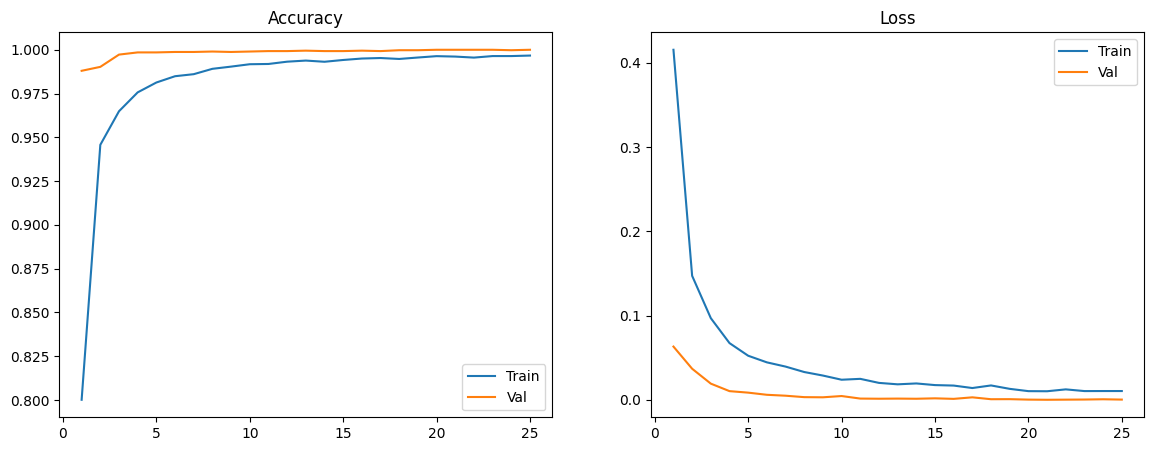

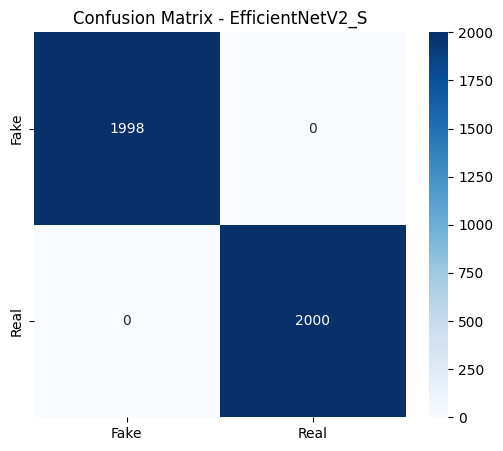

✅ EfficientNet Config D (Low LR) - Done.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION (EfficientNet - CONFIG D - LOW LR) ---
RUN_NAME       = "Final_Prototype_Universal_EfficientNet_ConfigD"   # <--- CONFIG D
MODEL_ARCH     = "EfficientNetV2_S"
BATCH_SIZE     = 16
LEARNING_RATE  = 0.00001
OPTIMIZER_NAME = "Adam"
NUM_EPOCHS     = 50
PATIENCE       = 5

SAVE_DIR = f"/content/drive/MyDrive/FYP_Project/Models/{MODEL_ARCH}/{RUN_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📂 Saving results to: {SAVE_DIR}")

# --- 2. SETUP DATA & MODEL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Starting {MODEL_ARCH} - {RUN_NAME} on {device}...")

# USING THE "NUCLEAR" AUGMENTATIONS
data_transforms = {
    'Train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/dataset/04_Universal_Dataset'


if os.path.exists(data_dir):
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['Train', 'Val']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2) for x in ['Train', 'Val']}
    dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Val']}
    print(f"📊 Dataset Stats: Train={dataset_sizes['Train']}, Val={dataset_sizes['Val']}")

    print(image_datasets['Train'].classes)
else:
    print("❌ ERROR: Dataset not found.")
    exit()

# --- LOAD EFFICIENTNET V2 ---
print(f"⏳ Loading {MODEL_ARCH} weights...")
model = models.efficientnet_v2_s(weights='DEFAULT')

# EfficientNet Head Replacement
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 2)
model = model.to(device)

if OPTIMIZER_NAME == "Adam":
    print(f"⚙️ Using Adam (LR={LEARNING_RATE})")
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZER_NAME == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

criterion = nn.CrossEntropyLoss()

# --- 3. TRAINING LOOP ---
since = time.time()
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
early_stop_counter = 0
history = []

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)
    epoch_stats = {'Epoch': epoch+1}

    for phase in ['Train', 'Val']:
        if phase == 'Train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0
        all_labels = []
        all_preds = []
        all_probs_fake = []

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'Train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if phase == 'Val':
                probs = torch.nn.functional.softmax(outputs, dim=1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs_fake.extend(probs[:, 0].cpu().detach().numpy())

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        epoch_stats[f'{phase}_Loss'] = epoch_loss
        epoch_stats[f'{phase}_Acc'] = epoch_acc.item()

        if phase == 'Val':
            binary_labels = [1 if x == 0 else 0 for x in all_labels]
            binary_preds  = [1 if x == 0 else 0 for x in all_preds]

            prec = precision_score(binary_labels, binary_preds, zero_division=0)
            rec  = recall_score(binary_labels, binary_preds, zero_division=0)
            f1   = f1_score(binary_labels, binary_preds, zero_division=0)
            try: auc = roc_auc_score(binary_labels, all_probs_fake)
            except: auc = 0.5
            tn, fp, fn, tp = confusion_matrix(binary_labels, binary_preds).ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"   📊 Precision: {prec:.4f} | Recall: {rec:.4f} | Spec: {specificity:.4f} | AUC: {auc:.4f}")

            epoch_stats['Precision'] = prec
            epoch_stats['Recall'] = rec
            epoch_stats['Specificity'] = specificity
            epoch_stats['F1'] = f1
            epoch_stats['AUC'] = auc

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1

    history.append(epoch_stats)
    if early_stop_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

# Save & Plot
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_metrics.csv"), index=False)

df = pd.DataFrame(history)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(df['Epoch'], df['Train_Acc'], label='Train'); plt.plot(df['Epoch'], df['Val_Acc'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(df['Epoch'], df['Train_Loss'], label='Train'); plt.plot(df['Epoch'], df['Val_Loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_plots.png"))

# CM
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in dataloaders['Val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion Matrix - {MODEL_ARCH}')
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_conf_matrix.png"))
plt.show()

print("✅ EfficientNet Config D (Low LR) - Done.")

In [ ]:
# --- 1. SETUP & UNZIP ---
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/FYP_Project/Final_Thesis_Benchmarks.zip'
extract_path = '/content/Final_Benchmarks'

if not os.path.exists(extract_path):
    print("📂 Unzipping Final Benchmarks...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Unzipped!")
else:
    print("✅ Benchmarks already exist.")

root_bench = os.path.join(extract_path, "Final_Thesis_Benchmarks")
if not os.path.exists(root_bench):
    root_bench = extract_path

print(f"📍 Benchmark Root: {root_bench}")
print(f"   Contents: {os.listdir(root_bench)}")

# --- 2. LIBRARIES & CONFIG ---
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

# PATH TO YOUR TRAINED PROTOTYPE
MODEL_PATH = "/content/drive/MyDrive/FYP_Project/Models/EfficientNetV2_S/Final_Prototype_Universal_EfficientNet_ConfigD/EfficientNetV2_S_Final_Prototype_Universal_EfficientNet_ConfigD_model.pth"
OUTPUT_DIR = "/content/drive/MyDrive/FYP_Project/Final_Results/Final_Prototype_Analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 3. MODEL & GRAD-CAM SETUP ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output): self.activations = output
    def save_gradient(self, module, grad_input, grad_output): self.gradients = grad_output[0]

    def __call__(self, x):
        output = self.model(x)
        idx = torch.argmax(output, dim=1)
        self.model.zero_grad()
        output[0, idx].backward()

        grads = self.gradients[0].cpu().data.numpy()
        acts = self.activations[0].cpu().data.numpy()

        weights = np.mean(grads, axis=(1, 2))
        cam = np.zeros(acts.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam, idx

def save_visual(img_tensor, heatmap, true_lbl, pred_lbl, conf, path):
    # Denormalize
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = np.float32(heatmap_colored) / 255
    heatmap_colored = heatmap_colored[..., ::-1] # BGR to RGB

    superimposed = 0.6 * img + 0.4 * heatmap_colored
    superimposed = superimposed / np.max(superimposed)

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed)
    plt.axis('off')
    status = "✅" if true_lbl == pred_lbl else "❌"
    plt.title(f"{status} True: {true_lbl} | Pred: {pred_lbl} ({conf:.1f}%)")
    plt.savefig(path, bbox_inches='tight')
    plt.close()

# LOAD MODEL
print("⏳ Loading Final Prototype Model...")
model = models.efficientnet_v2_s(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# Hook Grad-CAM to the last feature block of EfficientNetV2
grad_cam = GradCAM(model, model.features[-1])

# --- 4. EVALUATION LOOP ---
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class SimpleDataset(Dataset):
    def __init__(self, folder, transform):
        self.files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg'))]
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        return self.transform(img), self.files[idx]

def evaluate_subset(name, folder_name, true_label_idx):
    folder_path = os.path.join(root_bench, folder_name)
    if not os.path.exists(folder_path):
        print(f"⚠️ Missing Folder: {folder_path}")
        return None

    ds = SimpleDataset(folder_path, data_transforms)
    dl = DataLoader(ds, batch_size=32, shuffle=False)

    print(f"\n⚙️ Testing {name} ({len(ds)} images)...")

    correct = 0
    total = 0
    viz_count = 0

    viz_dir = os.path.join(OUTPUT_DIR, name)
    os.makedirs(viz_dir, exist_ok=True)

    for inputs, paths in dl:
        inputs = inputs.to(DEVICE)

        # 1. Prediction
        with torch.no_grad():
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

        # 2. Metrics
        # True Label: 1 for Real, 0 for Fake
        target = torch.full_like(preds, true_label_idx)
        correct += (preds == target).sum().item()
        total += inputs.size(0)

        # 3. Grad-CAM (Only for first batch to save time)
        if viz_count < 5:
            # We need gradients, so run forward pass again with grad
            inputs.requires_grad = True
            heatmap, pred_idx = grad_cam(inputs[0].unsqueeze(0)) # Process first img of batch

            # Metadata
            conf = probs[0][pred_idx].item() * 100
            p_lbl = "Real" if pred_idx.item() == 1 else "Fake"
            t_lbl = "Real" if true_label_idx == 1 else "Fake"
            fname = os.path.basename(paths[0])

            save_visual(inputs[0].detach(), heatmap, t_lbl, p_lbl, conf,
                       os.path.join(viz_dir, f"GradCAM_{viz_count}_{fname}.png"))
            viz_count += 1

    acc = correct / total
    print(f"   👉 Accuracy: {acc*100:.2f}%")
    return acc

# RUN TESTS
final_stats = []

# 1. REAL CONTROL (Label = 1)
acc = evaluate_subset("Real_Control", "Real_Control", 1)
final_stats.append({"Dataset": "Real Control", "Type": "Biological", "Accuracy": acc})

# 2. DiT TEST (Label = 0)
acc = evaluate_subset("DiT_Deepfakes", "DiT_Test", 0)
final_stats.append({"Dataset": "DiT", "Type": "Synthetic (Transformer)", "Accuracy": acc})

# 3. GAN TEST (Label = 0)
acc = evaluate_subset("GAN_Deepfakes", "GAN_Test", 0)
final_stats.append({"Dataset": "GAN", "Type": "Synthetic (Adversarial)", "Accuracy": acc})

# 4. U-Net TEST (Label = 0)
acc = evaluate_subset("UNet_Deepfakes", "UNet_Test", 0)
final_stats.append({"Dataset": "U-Net", "Type": "Synthetic (Diffusion)", "Accuracy": acc})

# SAVE CSV
df = pd.DataFrame(final_stats)
df.to_csv(os.path.join(OUTPUT_DIR, "Final_Thesis_Benchmark_Scores.csv"), index=False)

print("\n🏆 FINAL THESIS SCORES 🏆")
print(df)
print(f"\n📂 Heatmaps saved to: {OUTPUT_DIR}")

Mounted at /content/drive
📂 Unzipping Final Benchmarks...
✅ Unzipped!
📍 Benchmark Root: /content/Final_Benchmarks/Final_Thesis_Benchmarks
   Contents: ['GAN_Test', 'UNet_Test', 'DiT_Test', 'Real_Control']
⏳ Loading Final Prototype Model...

⚙️ Testing Real_Control (2000 images)...


/tmp/ipython-input-1741816159.py:108: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inches='tight')


   👉 Accuracy: 100.00%

⚙️ Testing DiT_Deepfakes (2000 images)...
   👉 Accuracy: 98.10%

⚙️ Testing GAN_Deepfakes (2000 images)...
   👉 Accuracy: 100.00%

⚙️ Testing UNet_Deepfakes (1919 images)...
   👉 Accuracy: 99.58%

🏆 FINAL THESIS SCORES 🏆
        Dataset                     Type  Accuracy
0  Real Control               Biological  1.000000
1           DiT  Synthetic (Transformer)  0.981000
2           GAN  Synthetic (Adversarial)  1.000000
3         U-Net    Synthetic (Diffusion)  0.995831

📂 Heatmaps saved to: /content/drive/MyDrive/FYP_Project/Final_Results/Final_Prototype_Analysis


In [ ]:
# --- 1. SETUP & UNZIP ---
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

# PATHS
zip_path = '/content/drive/MyDrive/FYP_Project/Final_Thesis_Benchmarks.zip'
extract_path = '/content/Final_Benchmarks'
MODEL_PATH = "/content/drive/MyDrive/FYP_Project/Models/EfficientNetV2_S/Final_Prototype_Universal_EfficientNet_ConfigD/EfficientNetV2_S_Final_Prototype_Universal_EfficientNet_ConfigD_model.pth"
OUTPUT_DIR = "/content/drive/MyDrive/FYP_Project/Final_Results/Robustness_Test"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# UNZIP
if not os.path.exists(extract_path):
    print("📂 Unzipping Benchmarks...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Unzipped!")

root_bench = os.path.join(extract_path, "Final_Thesis_Benchmarks")
if not os.path.exists(root_bench): root_bench = extract_path

# --- 2. LIBRARIES & TRANSFORMS ---
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- CUSTOM NOISE TRANSFORM ---
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.05):
        self.std = std
        self.mean = mean
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

# --- DEFINE THE 3 GAUNTLETS ---
# 1. Clean (Baseline)
transform_clean = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Blur Attack (Kills GAN Artifacts)
transform_blur = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=1.5), # Force Blur
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Noise Attack (Simulates Bad Sensor)
transform_noise = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.05), # Add Noise
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

STRESS_TESTS = {
    "Baseline (Clean)": transform_clean,
    "Stress (Blurry)":  transform_blur,
    "Stress (Noisy)":   transform_noise
}

# --- 3. EVALUATION LOGIC ---
print("⏳ Loading Model...")
model = models.efficientnet_v2_s(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

class SimpleDataset(Dataset):
    def __init__(self, folder, transform):
        self.files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg'))]
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        return self.transform(img), 0 # Dummy label

def run_stress_test():
    results = []

    # Define Datasets
    # (Name, FolderName, TrueLabel) - 1=Real, 0=Fake
    datasets_to_test = [
        ("Real Control", "Real_Control", 1),
        ("DiT",          "DiT_Test",     0),
        ("GAN",          "GAN_Test",     0),
        ("U-Net",        "UNet_Test",    0)
    ]

    print(f"\n🚀 STARTING ROBUSTNESS STRESS TEST")
    print("="*40)

    for ds_name, folder_name, true_label in datasets_to_test:
        folder_path = os.path.join(root_bench, folder_name)
        if not os.path.exists(folder_path): continue

        print(f"\n📂 Dataset: {ds_name}")

        # Loop through Stress Conditions
        for stress_name, current_transform in STRESS_TESTS.items():
            # Create Loader with specific transform
            ds = SimpleDataset(folder_path, current_transform)
            dl = DataLoader(ds, batch_size=32, shuffle=False)

            correct = 0
            total = 0

            with torch.no_grad():
                for inputs, _ in dl:
                    inputs = inputs.to(DEVICE)
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)

                    target = torch.full_like(preds, true_label)
                    correct += (preds == target).sum().item()
                    total += inputs.size(0)

            acc = correct / total
            print(f"   👉 {stress_name}: {acc*100:.2f}%")

            results.append({
                "Dataset": ds_name,
                "Condition": stress_name,
                "Accuracy": acc
            })

    # Save
    df = pd.DataFrame(results)
    df.to_csv(os.path.join(OUTPUT_DIR, "Stress_Test_Results.csv"), index=False)

    # Pivot for pretty printing
    pivot_df = df.pivot(index="Dataset", columns="Condition", values="Accuracy")
    print("\n" + "="*40)
    print("🏆 FINAL ROBUSTNESS SCORES 🏆")
    print(pivot_df)
    print("\nFile saved to:", OUTPUT_DIR)

if __name__ == "__main__":
    run_stress_test()

Mounted at /content/drive
📂 Unzipping Benchmarks...
✅ Unzipped!
⏳ Loading Model...

🚀 STARTING ROBUSTNESS STRESS TEST

📂 Dataset: Real Control
   👉 Baseline (Clean): 100.00%
   👉 Stress (Blurry): 100.00%
   👉 Stress (Noisy): 95.65%

📂 Dataset: DiT
   👉 Baseline (Clean): 98.10%
   👉 Stress (Blurry): 99.05%
   👉 Stress (Noisy): 98.45%

📂 Dataset: GAN
   👉 Baseline (Clean): 100.00%
   👉 Stress (Blurry): 99.40%
   👉 Stress (Noisy): 96.80%

📂 Dataset: U-Net
   👉 Baseline (Clean): 99.58%
   👉 Stress (Blurry): 99.90%
   👉 Stress (Noisy): 99.84%

🏆 FINAL ROBUSTNESS SCORES 🏆
Condition     Baseline (Clean)  Stress (Blurry)  Stress (Noisy)
Dataset                                                        
DiT                   0.981000         0.990500        0.984500
GAN                   1.000000         0.994000        0.968000
Real Control          1.000000         1.000000        0.956500
U-Net                 0.995831         0.998958        0.998437

File saved to: /content/drive/MyDrive/FYP_

In [ ]:
# --- 1. SETUP & PATHS ---
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import pandas as pd
import zipfile

zip_path = '/content/drive/MyDrive/FYP_Project/Final_Thesis_Benchmarks.zip'
extract_path = '/content/Final_Benchmarks'
root_bench = os.path.join(extract_path, "Final_Thesis_Benchmarks")

if not os.path.exists(root_bench):
    print("📂 Unzipping Benchmarks...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    if not os.path.exists(root_bench): root_bench = extract_path

MODEL_PATH = "/content/drive/MyDrive/FYP_Project/Models/EfficientNetV2_S/Final_Prototype_Universal_EfficientNet_ConfigD/EfficientNetV2_S_Final_Prototype_Universal_EfficientNet_ConfigD_model.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. DEFINE TRAINING AUGMENTATIONS ---
# This matches your Training Phase EXACTLY
transform_training_style = transforms.Compose([
    transforms.Resize((224, 224)),
    # geometric distortions
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    # color distortions
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    # The GAN-Safe Blur (0.1 - 0.5)
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 0.5)),
    # Finalize
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("⏳ Loading Final Prototype...")
model = models.efficientnet_v2_s(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# --- 4. RUN TEST LOOP ---
class SimpleDataset(Dataset):
    def __init__(self, folder, transform):
        self.files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg'))]
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        return self.transform(img), 0 # Dummy label

datasets_to_test = [
    ("Real Control", "Real_Control", 1), # True Label 1
    ("DiT",          "DiT_Test",     0), # True Label 0
    ("GAN",          "GAN_Test",     0),
    ("U-Net",        "UNet_Test",    0)
]

print(f"\n🚀 STARTING ROBUSTNESS TEST (Training Augmentations Applied)")
print("   (Note: Results may vary slightly each run due to randomness)")
print("="*60)

results = []

for ds_name, folder_name, true_label in datasets_to_test:
    folder_path = os.path.join(root_bench, folder_name)
    if not os.path.exists(folder_path):
        print(f"⚠️ Missing: {folder_path}")
        continue

    # Use the HEAVY Augmentations
    ds = SimpleDataset(folder_path, transform_training_style)
    dl = DataLoader(ds, batch_size=32, shuffle=False)

    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, _ in dl:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            target = torch.full_like(preds, true_label)
            correct += (preds == target).sum().item()
            total += inputs.size(0)

    acc = correct / total
    print(f"📂 {ds_name:15} | Accuracy: {acc*100:.2f}%")
    results.append({"Dataset": ds_name, "Condition": "Augmented", "Accuracy": acc})

# SAVE
OUTPUT_DIR = "/content/drive/MyDrive/FYP_Project/Final_Results/Robustness_Test"
os.makedirs(OUTPUT_DIR, exist_ok=True)
pd.DataFrame(results).to_csv(os.path.join(OUTPUT_DIR, "Augmented_Test_Results.csv"), index=False)
print("\n✅ Done. Results saved to:", OUTPUT_DIR)

⏳ Loading Final Prototype...

🚀 STARTING ROBUSTNESS TEST (Training Augmentations Applied)
   (Note: Results may vary slightly each run due to randomness)
📂 Real Control    | Accuracy: 99.45%
📂 DiT             | Accuracy: 95.00%
📂 GAN             | Accuracy: 96.05%
📂 U-Net           | Accuracy: 97.60%

✅ Done. Results saved to: /content/drive/MyDrive/FYP_Project/Final_Results/Robustness_Test
